In [2]:
import pandas as pd

In [4]:
heart_disease = pd.read_csv('heart.csv')

In [5]:
heart_disease.shape

(1025, 14)

In [6]:
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# I want to compare the average max heart rate for healthy vs heart disease patients
print(heart_disease.groupby('target')['thalach'].mean())

target
0    139.130261
1    158.585551
Name: thalach, dtype: float64


In [ ]:
# Check which chest pain type has the highest percentage of heart disease cases
print(heart_disease.groupby('cp')['target'].mean() * 100)

cp
0    24.547284
1    80.239521
2    77.112676
3    66.233766
Name: target, dtype: float64


In [11]:
# Calculate the average max heart rate grouped by BOTH chest pain type and target
print(heart_disease.groupby(['cp', 'target'])['thalach'].mean())

cp  target
0   0         136.069333
    1         152.295082
1   0         152.090909
    1         164.664179
2   0         143.415385
    1         158.589041
3   0         156.115385
    1         157.647059
Name: thalach, dtype: float64


Target Distribution (%):
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_26164\252973704.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=heart_disease, x='target', palette='Set2')


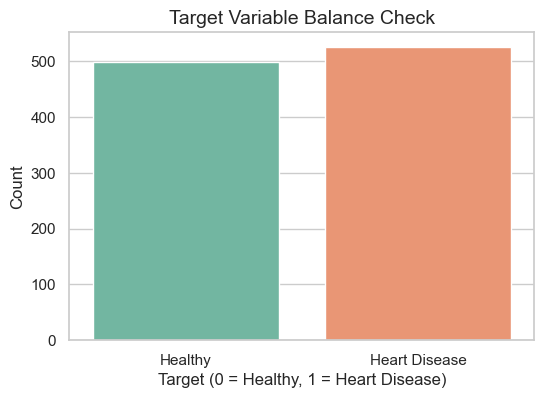

In [ ]:
import matplotlib.pyplot as plt

# Check raw value distribution as percentages
target_counts = heart_disease['target'].value_counts(normalize=True) * 100
print("Target Distribution (%):")
print(target_counts)

# Plot the target balance visually
plt.figure(figsize=(6, 4))
sns.countplot(data=heart_disease, x='target', palette='Set2')
plt.title("Target Variable Balance Check", fontsize=14)
plt.xlabel("Target (0 = Healthy, 1 = Heart Disease)")
plt.ylabel("Count")
plt.xticks([0, 1], ['Healthy', 'Heart Disease'])
plt.show()

In [12]:
# Calculate the linear correlation between all numerical features
correlation_matrix = heart_disease.corr()

# Let's see how everything correlates specifically with our target variable
print(correlation_matrix['target'].sort_values(ascending=False))

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


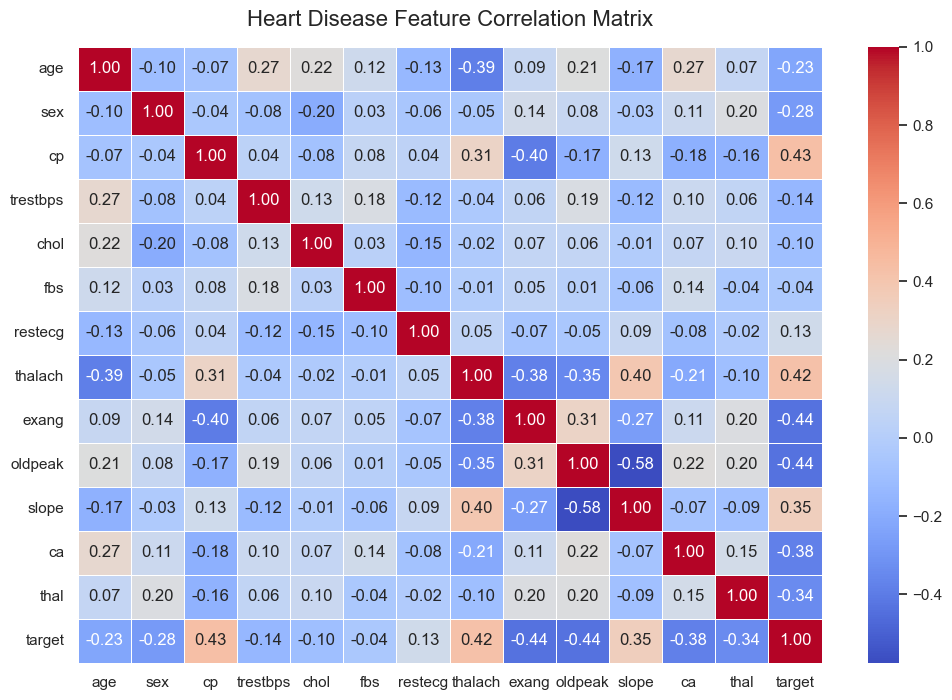

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and size of our canvas
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Calculate correlation
corr = heart_disease.corr()

# Plot the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Heart Disease Feature Correlation Matrix", fontsize=16, pad=15)
plt.show()